In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp
from IPython.display import display, Math

---

# Question 1: 

---

### Section A - Finding H(z) and Stability Condition

We are given the causal difference equation:
$$y(n) - a^2y(n-2) = 0.5x(n)$$

Applying the Z-transform (time-shift property):
$$Y(z) - a^2z^{-2}Y(z) = 0.5X(z)$$

The transfer function is therefore:
$$H(z) = \frac{Y(z)}{X(z)} = \frac{0.5z^2}{z^2 - a^2}$$

Setting the denominator to zero gives the poles:
$$z = \pm a$$

A causal system is stable if and only if all its poles lie inside the unit circle, so the stability condition is:
$$|a| < 1$$

In [18]:
# Choose value for 'a' (must be between -1 and 1 for stability)
a = 0.5
# Define the denominator of H(z):z^2-a^2
# The numbers are the coefficients: [z^2, z^1, z^0]
denominator = [1.0, 0.0, -(a**2)]
# Find the poles (roots of the denominator)
poles = np.roots(denominator)

print(f"Testing for a = {a}:")
print(f"The poles are:{poles}")

# Check if all poles are inside the unit circle (absolute value < 1)
is_stable = all(np.abs(poles) < 1)

if is_stable:
    print("Conclusion: The system is STABLE (all poles < 1)")
else:
    print("Conclusion: The system is UNSTABLE")

Testing for a = 0.5:
The poles are:[ 0.5 -0.5]
Conclusion: The system is STABLE (all poles < 1)


### Section B - Finding the Impulse Response h(n)

To find the impulse response we return to the time domain.
The system is causal, so its region of convergence is the exterior of the circle that passes through the poles.

We found:
$$H(z) = \frac{0.5}{1 - a^2z^{-2}}$$

Factoring the denominator (difference of squares) and using partial fractions:
$$\frac{0.5}{(1 - az^{-1})(1 + az^{-1})} = \frac{A}{1 - az^{-1}} + \frac{B}{1 + az^{-1}}$$

This gives:
$$A = 0.25, B = 0.25$$

Using the transform pair:
$$\frac{1}{1 - \alpha z^{-1}} \rightarrow \alpha^n u(n)$$

we get:
$$h(n) = 0.25a^n u(n) + 0.25(-a)^n u(n)$$

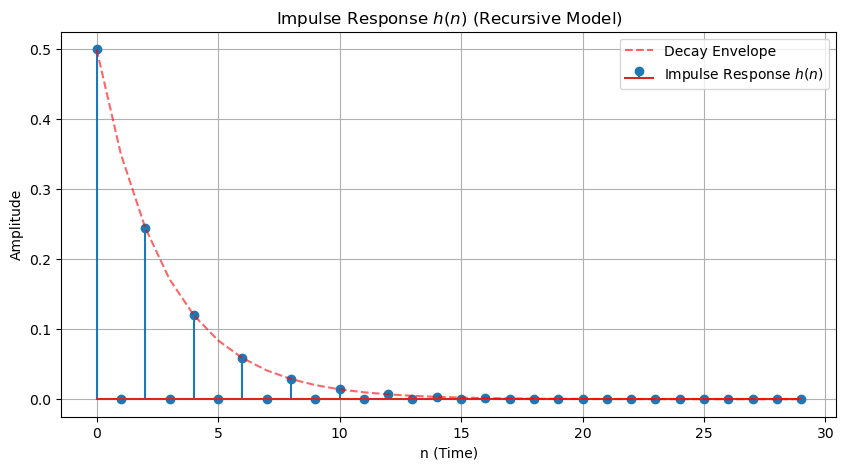

In [36]:
a=0.7
# define time array
n=np.arange(-500,500)

#create the input signal x[n]
x=np.zeros(1000)
x[500]=1.0

#create the output array y[n] 
y=np.zeros(1000)

#Calculate the difference equation recursively
for i in range(2, 1000):
    y[i] = (a**2) * y[i-2] + 0.5 * x[i]

# Slice the arrays to show only the relevant part in the plot (from n=0 to n=30)
n_plot = n[500:530]
y_plot = y[500:530]

# Create the decay envelope (using only even values)
envelope = 0.5 * (a**n_plot)

# Plot the graph
plt.figure(figsize=(10, 5))
plt.stem(n_plot, y_plot, label='Impulse Response $h(n)$') 
plt.plot(n_plot, envelope, 'r--', alpha=0.6, label='Decay Envelope')
plt.title('Impulse Response $h(n)$ (Recursive Model)')
plt.xlabel('n (Time)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

**Plot analysis:**
The plot shows the impulse response $h(n)$ in the time domain. Because of the $z^{-2}$ term in the transfer function, the signal is non-zero **only at even times** ($n=0, 2, 4...$). At odd times the two terms cancel each other and the response is exactly zero.
The dashed line (the envelope) shows the exponential decay of the signal as $n$ grows. This decay confirms that the system is stable: the response is bounded and tends to zero.

### Section C - Frequency Response and Filter Type

To find the frequency response, we substitute $z = e^{j\omega}$ into the transfer function:
$$H(e^{j\omega}) = \frac{0.5}{1 - a^2e^{-j2\omega}}$$

To find the squared magnitude, we multiply by the complex conjugate, $|H(e^{j\omega})|^2 = H(e^{j\omega}) \cdot H^*(e^{j\omega})$:
$$|H(e^{j\omega})|^2 = \left( \frac{0.5}{1 - a^2 e^{-j2\omega}} \right) \cdot \left( \frac{0.5}{1 - a^2 e^{+j2\omega}} \right)$$

Expanding the denominator:
$$|H(e^{j\omega})|^2 = \frac{0.25}{1 + a^4 - a^2(e^{j2\omega} + e^{-j2\omega})}$$

Using Euler's identity $e^{j\theta} + e^{-j\theta} = 2\cos(\theta)$ we obtain the magnitude response:
$$|H(e^{j\omega})|^2 = \frac{0.25}{1 + a^4 - 2a^2\cos(2\omega)}$$

**Filter type:**
The only frequency dependence is through $\cos(2\omega)$, so the filtering is periodic.
The filter amplifies frequencies where $\cos(2\omega)=1$ (around integer multiples of $\pi$) and attenuates frequencies where $\cos(2\omega)=-1$ (around odd multiples of $\frac{\pi}{2}$).

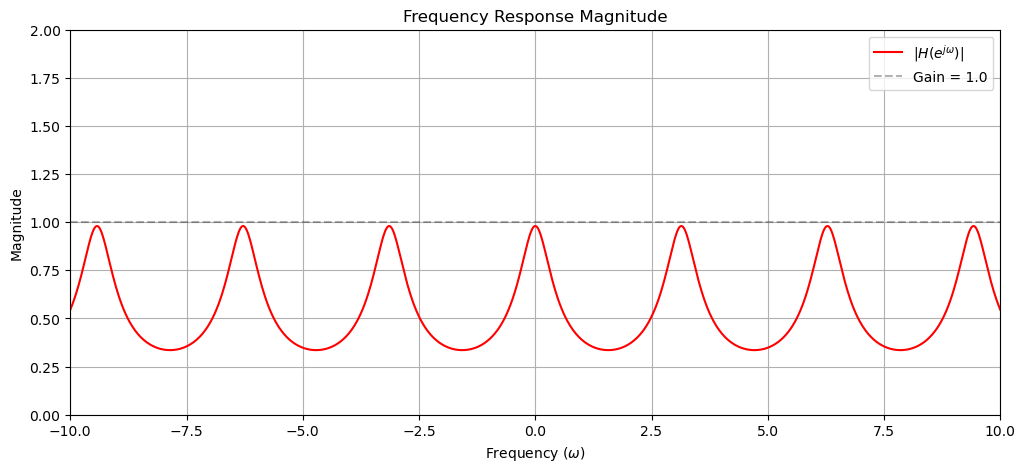

In [9]:
# Choose a value for 'a'
a = 0.7

# Define the continuous frequency axis 'omega' (from -10 to 10 with 1000 points)
w = np.linspace(-10, 10, 1000)

# Calculate the Magnitude |H(e^jw)| (taking the square root)
magnitude = 0.5 / np.sqrt(1 + a**4 - 2 * a**2 * np.cos(2 * w))

# Plotting the graph
plt.figure(figsize=(12, 5))
plt.plot(w, magnitude, color='red', label=r'$|H(e^{j\omega})|$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3, label='Gain = 1.0')
plt.ylim(0, 2)    
plt.xlim(-10, 10)
plt.title('Frequency Response Magnitude')
plt.xlabel(r'Frequency ($\omega$)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.legend()
plt.show()


 

**Plot analysis:**
The plot shows the magnitude of the original frequency response $|H(e^{j\omega})|$. Discrete-time frequency responses are always $2\pi$-periodic, but because the impulse response is non-zero only at even times, the spectrum is compressed and the response is periodic with period $\pi$.
As a result there are peaks both at $\omega=0$ and at $\omega=\pm \pi$. In practice the system passes very low and very high frequencies and sharply attenuates the frequencies in between (around $\pm \frac{\pi}{2}$).

### Section D.1 - Frequency Response of $h_1(n) = (-1)^n h(n)$

The factor $(-1)^n$ is equal to the complex exponential $e^{j\pi n}$.

By the frequency-shift property, multiplying a signal by $e^{j\omega_0 n}$ in time shifts its spectrum by $\omega_0$. Here $\omega_0 = \pi$.

Normally, a shift of $\pi$ turns a low-pass filter (LPF) into a high-pass filter (HPF).
However, our impulse response $h(n)$ is non-zero **only at even times** ($n=2k$), and for every even $n$ we have $(-1)^n = 1$.

So the multiplication does not change any sample, and $h_1(n) = h(n)$.
As a result, the frequency response is identical to the one in the previous section.

Filter type: band-stop (passes the edges, blocks the middle).

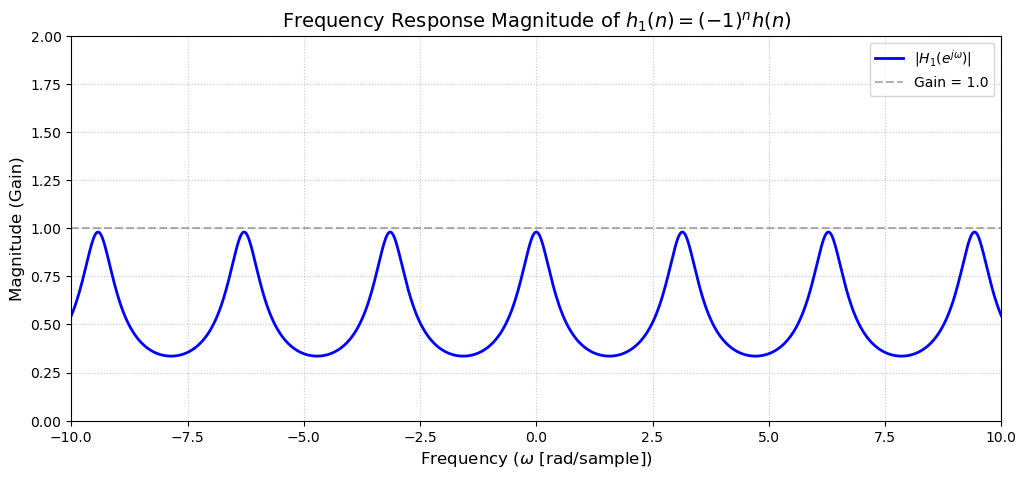

In [12]:
a = 0.7

# Define the continuous frequency axis 'omega' (from -10 to 10 with 1000 points)
w = np.linspace(-10, 10, 1000)

# using the former formula
magnitude_h1 = 0.5 / np.sqrt(1 + a**4 - 2 * a**2 * np.cos(2 * w))

# Plotting the graph for D.1
plt.figure(figsize=(12, 5))
plt.plot(w, magnitude_h1, color='blue', linewidth=2, label=r'$|H_1(e^{j\omega})|$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3, label='Gain = 1.0')
plt.title(r'Frequency Response Magnitude of $h_1(n) = (-1)^n h(n)$', fontsize=14)
plt.xlabel(r'Frequency ($\omega$ [rad/sample])', fontsize=12)
plt.ylabel('Magnitude (Gain)', fontsize=12)
plt.ylim(0, 2)
plt.xlim(-10, 10)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend(loc='upper right')
plt.show()



**Plot analysis (Section D.1):**
Here the impulse response was multiplied by $(-1)^n$, which is mathematically the same as multiplying by $e^{j\pi n}$.
By the properties of the Fourier transform this shifts the frequency response by $\pi$.
However, as the plot shows, **the result is identical to the original plot from Section C.** The reason is that the original system is already periodic with period $\pi$ (because of the $\cos(2\omega)$ term in the denominator). Shifting it by exactly one full period brings it back to the same curve, so there is no visible change.

### Section D.2 - Frequency Response of $h_2(n) = e^{j\frac{\pi}{2}n} h(n)$

By the frequency-shift property, multiplying the signal by $e^{j\frac{\pi}{2}n}$ in time shifts the frequency response to the right by $\frac{\pi}{2}$.

The relation between the two frequency responses is:
$$H_2(e^{j\omega}) = H(e^{j(\omega - \frac{\pi}{2})})$$

In Section C, the maxima were at multiples of $\pi$: $0, \pi, 2\pi \dots$
and the minima were at $\frac{\pi}{2}, \frac{3\pi}{2} \dots$

Since the whole curve is shifted by $\frac{\pi}{2}$, maxima and minima swap places: where there was a maximum there is now a minimum, and vice versa.
The filter changes its character: it now passes frequencies around $\pi/2$ instead of frequencies around $0$ and $\pi$.

Filter type: band-pass (passes the middle band, blocks the edges).

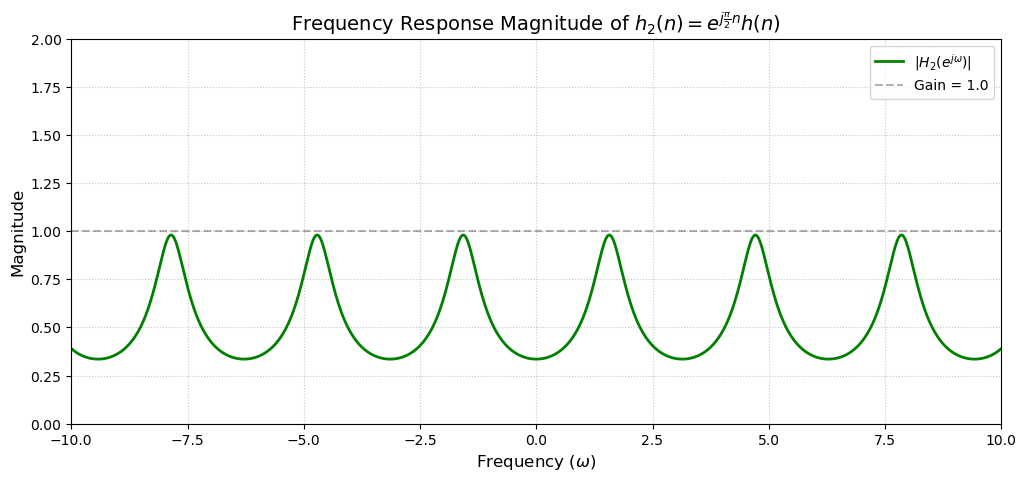

In [15]:
a = 0.7

# Define the continuous frequency axis 'omega' (from -10 to 10 with 1000 points)
w = np.linspace(-10, 10, 1000)

# # Calculate the magnitude with the frequency shift (omega - pi/2)
magnitude_h2 = 0.5 / np.sqrt(1 + a**4 - 2 * a**2 * np.cos(2 * (w-np.pi/2)))

# Plotting the graph for D.2
plt.figure(figsize=(12, 5))
plt.plot(w, magnitude_h2, color='green', linewidth=2, label=r'$|H_2(e^{j\omega})|$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3, label='Gain = 1.0')
plt.title(r'Frequency Response Magnitude of $h_2(n) = e^{j\frac{\pi}{2}n} h(n)$', fontsize=14)
plt.xlabel(r'Frequency ($\omega$)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.ylim(0, 2)
plt.xlim(-10, 10)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend(loc='upper right')
plt.show()



**Plot analysis:**
This plot shows the frequency response after multiplying the impulse response by $e^{j\frac{\pi}{2}n}$. As shown above, this multiplication in time shifts the spectrum by $\frac{\pi}{2}$. The peaks that were at zero and at $\pi$ have clearly moved by exactly this amount, and the system now passes a different set of frequencies.

### Section D.3 - Frequency Response of $h_3(n) = h(n) * \left(e^{j\frac{\pi}{2}n} h(n)\right)$

The expression is a convolution between the original impulse response $h(n)$ and the impulse response from D.2, which we denote $h_2(n)$:
$h_3(n) = h(n) * h_2(n)$.

By the convolution theorem, convolution in time equals multiplication in frequency. We multiply the two frequency responses found above:
$$H_3(e^{j\omega}) = H(e^{j\omega}) \cdot H_2(e^{j\omega}) = \left(\frac{0.5}{1 - a^2 e^{-j2\omega}}\right) \cdot \left(\frac{0.5}{1 + a^2 e^{-j2\omega}}\right)$$

Using the difference of squares $(1-x)(1+x) = 1-x^2$ in the denominator:
$$H_3(e^{j\omega}) = \frac{0.25}{1 - a^4 e^{-j4\omega}}$$

**Filter type and effect:**
This is a comb filter. There are two main changes:
1. The gain drops (a factor of $0.25$ in the numerator and $a^4$ in the denominator).
2. The frequency is doubled ($4\omega$ appears), so the period is halved and the filter now passes frequencies at every multiple of $\frac{\pi}{2}$ instead of every multiple of $\pi$.

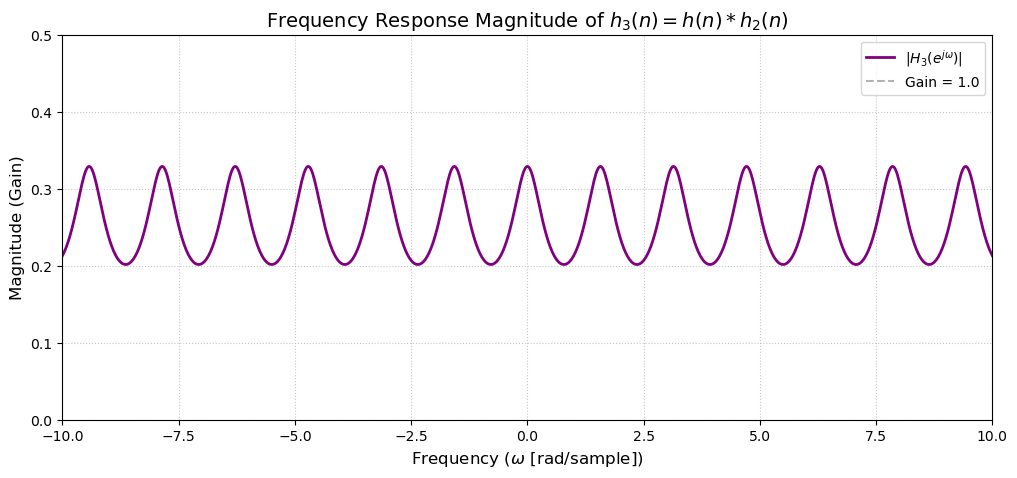

In [18]:
a = 0.7

# Define the continuous frequency axis 'omega' (from -10 to 10 with 1000 points)
w = np.linspace(-10, 10, 1000)

# Calculate the magnitude
magnitude_h3 = 0.25 / np.sqrt(1 + a**8 - 2 * a**4 * np.cos(4 * w))

# Plotting the graph
plt.figure(figsize=(12, 5))
plt.plot(w, magnitude_h3, color='purple', linewidth=2, label=r'$|H_3(e^{j\omega})|$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3, label='Gain = 1.0')
plt.title(r'Frequency Response Magnitude of $h_3(n) = h(n) * h_2(n)$', fontsize=14)
plt.xlabel(r'Frequency ($\omega$ [rad/sample])', fontsize=12)
plt.ylabel('Magnitude (Gain)', fontsize=12)
plt.ylim(0, 0.5)
plt.xlim(-10, 10)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

**Plot analysis (Section D.3):**
This plot shows the magnitude response of the two previous filters connected in cascade. The result is a filter whose periodic pattern is twice as dense. Because of the $4\omega$ term in the denominator, the maxima now appear every $\frac{\pi}{2}$ (instead of every $\pi$ in the original system). In addition, since the two responses are multiplied, the overall peak gain drops from 0.5 to 0.25.

### Section E - System Output for the Cascaded Filter

This section considers a system made of $M$ blocks connected in cascade.
In each block, the impulse response is multiplied by an exponential of the form $e^{-j\frac{k\pi}{M}n}$ (for $k=0, 1, \dots, M-1$).
By the properties of the Z-transform, multiplying by an exponential in time scales the Z-plane:
$$Z\{e^{-j\frac{k\pi}{M}n} h(n)\} = H(e^{j\frac{k\pi}{M}}z) = \frac{0.5}{1 - a^2 e^{-j\frac{2k\pi}{M}} z^{-2}}$$

Since the blocks are in cascade, the overall transfer function $H_4(z)$ is the **product** of the individual transfer functions:
$$H_4(z) = \prod_{k=0}^{M-1} \frac{0.5}{1 - a^2 e^{-j\frac{2k\pi}{M}} z^{-2}} = \frac{0.5^M}{\prod_{k=0}^{M-1} (1 - a^2 e^{-j\frac{2k\pi}{M}} z^{-2})}$$

Using the roots-of-unity identity we get:
$$H_4(z) = \frac{0.5^M}{1 - a^{2M} z^{-2M}}$$

The given input signal is $x(n) = \delta(n) - a^{2M}\delta(n-2M)$.
Its Z-transform is exactly the denominator of the system:
$$X(z) = 1 - a^{2M} z^{-2M}$$

**Computing the output:**
Multiplying the input by the system response in the Z-domain:
$$Y(z) = X(z) \cdot H_4(z) = (1 - a^{2M} z^{-2M}) \cdot \left(\frac{0.5^M}{1 - a^{2M} z^{-2M}}\right) = 0.5^M$$

Since $Y(z)$ is a constant, its inverse transform is a single impulse:
$$y(n) = 0.5^M \delta(n)$$

**Conclusion:** the long cascade is built so that it exactly cancels the delayed component of the input, leaving only an attenuated impulse at $n=0$.

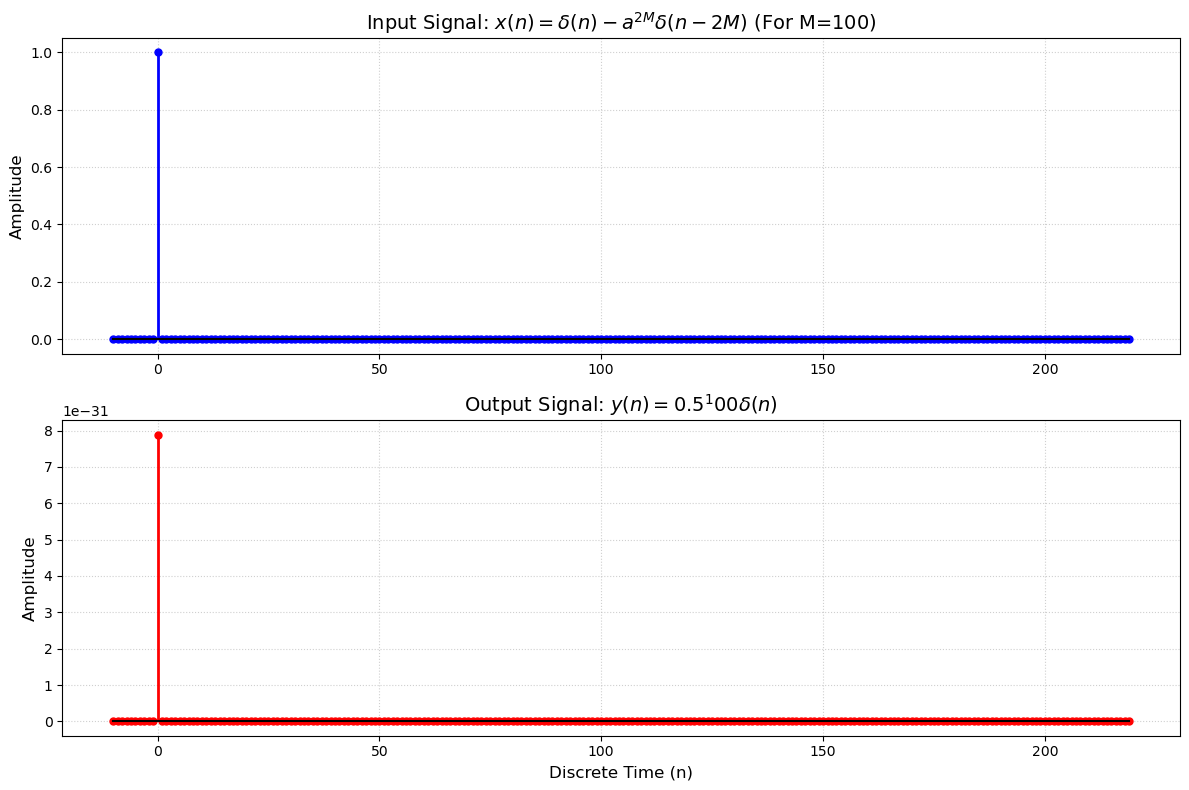

In [43]:
# Define system parameters for the simulation
a = 0.7
M = 100

# Define the time vector 'n' (from -10 to 219)
n = np.arange(-10, 220)

# Create the input signal x(n)
# x(n) = delta(n) - a^(2M) * delta(n-2M)
x_n = np.zeros_like(n, dtype=float)
y_n = np.zeros_like(n, dtype=float)

# Find the exact indexes in the array for n=0 and n=2M
idx_0 = np.where(n == 0)[0][0]
idx_2M = np.where(n == 2*M)[0][0]

# Build the input signal x(n)
# x(n) = delta(n) - a^(2M) * delta(n-2M)
x_n[idx_0] = 1.0                          
x_n[idx_2M] = -(a**(2*M))                 

# Build the output signal y(n)
# y(n) = (0.5^M) * delta(n)
y_n[idx_0] = 0.5**M                       

# Plot the signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
markerline, stemlines, baseline = ax1.stem(n, x_n, basefmt="k-")
plt.setp(stemlines, 'color', 'blue', 'linewidth', 2)
plt.setp(markerline, 'color', 'blue', 'markersize', 5)
ax1.set_title(rf'Input Signal: $x(n) = \delta(n) - a^{{2M}}\delta(n-2M)$ (For M={M})', fontsize=14)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

markerline, stemlines, baseline = ax2.stem(n, y_n, basefmt="k-")
plt.setp(stemlines, 'color', 'red', 'linewidth', 2)
plt.setp(markerline, 'color', 'red', 'markersize', 5)
ax2.set_title(rf'Output Signal: $y(n) = 0.5^{M} \delta(n)$', fontsize=14)
ax2.set_xlabel('Discrete Time (n)', fontsize=12)
ax2.set_ylabel('Amplitude', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


**Plot analysis (Section E):**
The plots show the cascaded system in the time domain, with the delay parameter set to $M=100$:
* **Top plot (input):** the input consists of an impulse at $n=0$ and an "echo" at $n=2M$. With $M=100$ the echo is pushed to $n=200$. Its amplitude is scaled by $a^{2M}$, so for a value such as $a=0.7$ it is practically zero and not visible in the plot.
* **Bottom plot (output):** after passing through the cascaded system, only a single impulse at $n=0$ remains. The system completely cancels the echo. However, because $M$ is large, the desired impulse is also heavily attenuated (by a factor of $0.5^M$), so its amplitude is essentially zero.

**Conclusion:**
The plots confirm that the cascaded structure works as a perfect echo canceller. They also show its practical cost: for very long delays the echo is removed, but the desired signal itself is attenuated to a negligible level.

---

# Question 2: DC-Motor Analysis (Differential Equations & Laplace)

---

### Section A - Single ODE for Motor Speed $w(t)$

Deriving the differential equation for the speed $w(t)$:
We use the second equation to isolate the current $i(t)$:
$$w(t) + w'(t) - i(t) = 0 \implies i(t) = w(t) + w'(t)$$

Differentiating with respect to time gives $i'(t)$:
$$i'(t) = w'(t) + w''(t)$$

Substituting both expressions into the first differential equation:
$$(R+1)[w(t) + w'(t)] + [w'(t) + w''(t)] + w(t) = 0$$

Expanding and collecting terms:
$$R w(t) + R w'(t) + w(t) + w'(t) + w'(t) + w''(t) + w(t) = 0$$

Finally, we obtain a second-order ODE for the motor speed:
$$w''(t) + (R+2)w'(t) + (R+2)w(t) = 0$$

In [26]:
# Define symbols and functions
t, R = sp.symbols('t R', real=True)
i = sp.Function('i')(t)
w = sp.Function('w')(t)

# setup the original ODEs
eq1 = (R + 1)*i + i.diff(t) + w
eq2 = w + w.diff(t) - i

# Isolate i(t) from eq2
i_expr = sp.solve(eq2, i)[0]

# Differentiate i(t) to get i'(t)
i_diff_expr = i_expr.diff(t)

# Substitute i(t) and i'(t) into eq1
final_ode = eq1.subs({i.diff(t): i_diff_expr, i: i_expr})

# simplify and group by derivatives
final_ode_simplified = sp.collect(sp.expand(final_ode), [w.diff(t, 2), w.diff(t), w])

# Display the resulting ODE
display(Math(r'\text{Differential Equation for } w(t):'))
display(Math(sp.latex(final_ode_simplified) + ' = 0'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Section B - Laplace Transform of the Motor Speed $W(s)$

Before transforming the ODE, we find the initial condition of the first derivative $w'(0)$.
Using the given ODE at $t=0$:
$$i(0) = w(0) + w'(0) \implies i_0 = w_0 + w'(0)$$
So the initial value of the derivative is:
$$w'(0) = i_0 - w_0$$

Now we apply the Laplace transform to the ODE from Section A:
$$w''(t) + (R+2)w'(t) + (R+2)w(t) = 0$$

Substituting the transforms of the derivatives, including initial conditions:
$$[s^2 W(s) - s w(0) - w'(0)] + (R+2)[s W(s) - w(0)] + (R+2)W(s) = 0$$

Substituting $w(0) = w_0$ and $w'(0) = i_0 - w_0$:
$$[s^2 W(s) - s w_0 - (i_0 - w_0)] + (R+2)[s W(s) - w_0] + (R+2)W(s) = 0$$

Collecting all terms containing $W(s)$ on one side and the initial-condition terms on the other:
$$W(s)[s^2 + (R+2)s + (R+2)] = s w_0 + i_0 - w_0 + w_0(R+2)$$

Isolating $W(s)$ gives the Laplace transform of the motor speed:
$$W(s) = \frac{w_0(R+2) + s w_0 + i_0 - w_0}{s^2 + (R+2)s + (R+2)}$$

In [29]:
# Define Laplace variable and initial conditions
s = sp.Symbol('s')
w_0, i_0 = sp.symbols(r'\omega_0 i_0', real=True)
W_s = sp.Function('W')(s)

# From eq2 at t=0, we find the initial condition for w'(0)
w_prime_0 = i_0 - w_0

# Define the Laplace transforms of the derivatives based on rules
L_w = W_s
L_w_prime = s * W_s - w_0
L_w_double_prime = s**2 * W_s - s * w_0 - w_prime_0

# Apply Laplace transform to the simplified ODE from Section A
laplace_ode = final_ode_simplified.subs({
    w.diff(t, 2): L_w_double_prime,
    w.diff(t): L_w_prime,
    w: L_w
})

# extract W(s)
W_solution = sp.solve(laplace_ode, W_s)[0]

# Simplify and collect terms for display
numerator, denominator = sp.fraction(sp.factor(W_solution))
W_solution_collected = sp.collect(sp.expand(numerator), s) / sp.collect(sp.expand(denominator), s)
display(Math(r'\text{Laplace Transform } W(s):'))
display(Math('W(s) = ' + sp.latex(W_solution_collected)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Section C - System Poles and Stability as a Function of $R$

The poles are the roots of the denominator of $W(s)$:
$$s^2 + (R+2)s + (R+2) = 0$$

Using the quadratic formula:
$$s_{1,2} = \frac{-(R+2) \pm \sqrt{(R+2)^2 - 4(R+2)}}{2}$$

Simplifying the discriminant:
$$\Delta = (R+2)^2 - 4(R+2) = R^2 + 4R + 4 - 4R - 8 = R^2 - 4$$

So the poles are:
$$s_{1,2} = \frac{-(R+2) \pm \sqrt{R^2 - 4}}{2}$$

**Number and location of the poles:**
Since $R$ is a physical resistance ($R \ge 0$), the nature of the poles is determined by the sign of $\Delta = R^2 - 4$:

1. **For $R > 2$ (overdamped):**
   The discriminant is positive. The system has **two distinct real poles** on the negative real axis (stable).

2. **For $R = 2$ (critically damped):**
   The discriminant is zero. The system has **one double real pole** at $s_{1,2} = \frac{-4 \pm 0}{2} = -2$.

3. **For $0 \le R < 2$ (underdamped):**
   The discriminant is negative. The system has **two complex-conjugate poles**.
   Their real part is $\frac{-(R+2)}{2}$ (always negative, so the system is stable), and their imaginary part is $\pm j\frac{\sqrt{4-R^2}}{2}$.

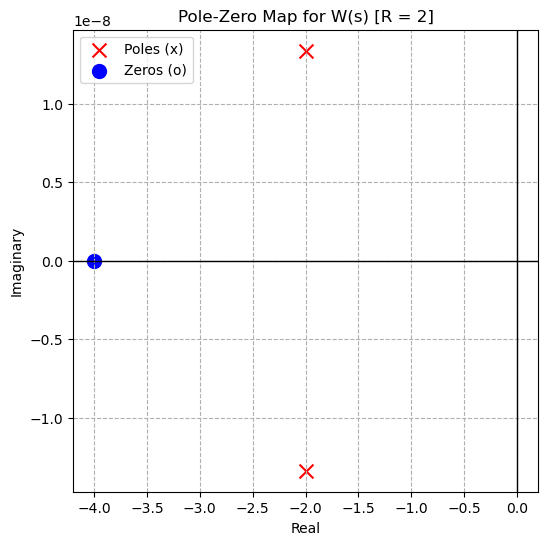

In [41]:
# Set values for initial conditions for the plot
w0_val = 1.0
i0_val = 1.0

# Helper function to plot Pole-Zero map 
def plot_pzmap(R_val):
    # Define numerator and denominator coefficients of the transfer function W(s)
    num = [w0_val, (R_val + 1)*w0_val + i0_val]
    den = [1, R_val + 2, R_val + 2]
    
    # Create the system
    system = signal.TransferFunction(num, den)
    poles = system.poles
    zeros = system.zeros

    # Plot the map
    plt.figure(figsize=(6, 6))
    plt.scatter(np.real(poles), np.imag(poles), s=100, marker='x', color='red', label='Poles (x)')
    if len(zeros) > 0:
        plt.scatter(np.real(zeros), np.imag(zeros), s=100, marker='o', color='blue', label='Zeros (o)')  
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.grid(True, linestyle='--')
    plt.title(f'Pole-Zero Map for W(s) [R = {R_val}]')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.legend()
    plt.show()

# Show the map for R=2 
plot_pzmap(R_val=2)


**Plot analysis (pole-zero map for the optimal case $R=2$):**
The plot shows the poles and zeros of the system in the complex s-plane:
* **Poles (red X):** the roots of the denominator, which determine the character of the response. As computed, for $R=2$ there is a double real pole at $s=-2$. Its position in the left half-plane means the system is stable (the speed decays to zero), and since it has no imaginary part the motor stops smoothly without oscillations (critical damping).
* **Zeros (blue O):** the roots of the numerator, created by the initial conditions ($w_0, i_0$). For the chosen values ($w_0=1, i_0=1$) there is a zero at $s=-4$. The zero affects the exact shape of the response at the first moments, but it does not change stability or the decay rate, which are set only by the poles.

### Section D - Optimal Resistance for Maximal Decay Rate

For the motor to stop as fast as possible without oscillating, we look for critical damping.
Mathematically, this happens when the discriminant is zero:
$$R^2 - 4 = 0 \implies R = 2$$
In this case there is a double pole at $s = -2$. This value gives the fastest decay without creating an imaginary part (which would cause oscillations).

**Why exactly $R=2$?**
* **For $R < 2$ (underdamped):** the motor does not stop directly. It oscillates back and forth before it settles.
* **For $R > 2$ (overdamped):** the motor takes a long time to stop. The high resistance weakens the current too much, and without current the motor has no "force" to brake quickly.

**Summary:** the optimal value for a smooth and fast stop is $R = 2$.

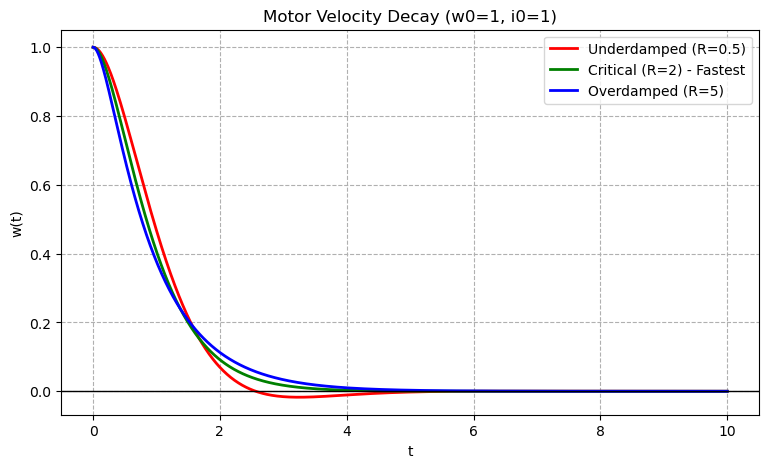

In [32]:
# plot motor speed for diff R
R_list = [0.5, 2.0, 5.0]
labels = ['Underdamped (R=0.5)', 'Critical (R=2) - Fastest', 'Overdamped (R=5)']
colors = ['red', 'green', 'blue']

t_vec = np.linspace(0, 10, 1000)
plt.figure(figsize=(9, 5))

for r, label, color in zip(R_list, labels, colors):
    # num for w0=1, i0=1 is s + r + 2
    # den is s^2 + (r+2)s + (r+2)
    sys_w = signal.TransferFunction([1, r + 2], [1, r + 2, r + 2])
    
    # use impulse to show initial state response
    _, w_out = signal.impulse(sys_w, T=t_vec)
    
    plt.plot(t_vec, w_out, label=label, color=color, linewidth=2)

plt.axhline(0, color='black', lw=1)
plt.title('Motor Velocity Decay (w0=1, i0=1)')
plt.xlabel('t')
plt.ylabel('w(t)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

**Plot analysis:**
The plot shows the time-domain behavior for different resistance values.
* **Red line ($R=0.5$):** underdamped. The oscillations before settling are clearly visible.
* **Blue line ($R=5$):** overdamped. The response is smooth with no oscillations, but it settles very slowly.
* **Green line ($R=2$):** critically damped. This is the fastest possible response without oscillations, which makes it the optimal value for braking the motor.

### Section E - Explicit Speed Equation $w(t)$

Computing the speed explicitly for the two extreme values of the resistance.
The transform derived earlier is:
$$W(s) = \frac{w_0(R+2) + s w_0 + i_0 - w_0}{s^2 + (R+2)s + (R+2)}$$

**Case 1: short circuit ($R=0$)**
Substituting zero for the resistance:
$$W(s) = \frac{w_0(s+1) + i_0}{s^2 + 2s + 2}$$
To invert the transform, we complete the square in the denominator and split the numerator into two fractions:
$$W(s) = w_0 \frac{s+1}{(s+1)^2 + 1} + i_0 \frac{1}{(s+1)^2 + 1}$$
So the time response is a combination of a decaying sine and cosine:
$$w(t) = e^{-t}[w_0 \cos(t) + i_0 \sin(t)]u(t)$$

**Case 2: open circuit ($R \to \infty$)**
As the resistance tends to infinity, the terms multiplied by $(R+2)$ dominate and the rest can be neglected:
$$W(s) \approx \frac{w_0(R+2)}{(R+2)(s+1)} = \frac{w_0}{s+1}$$
The inverse transform is a simple exponential decay:
$$w(t) = w_0 e^{-t} u(t)$$

**Does the motor stop?** Yes. Both expressions contain a decaying exponential ($e^{-t}$), so the speed always tends to zero over time.

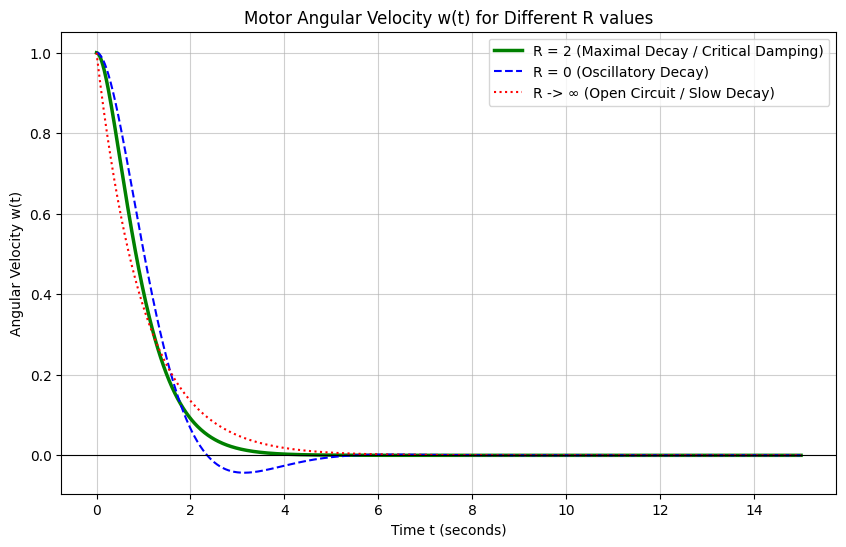

In [35]:
# Define the time axis (from 0 to 15 seconds)
t = np.linspace(0, 15,1000)

# Calculate w(t) for the 3 extreme cases:

# 1. For R = 2 (critical damping - maximum decay)
w_R2 = w0_val * np.exp(-2*t) + (i0_val + w0_val) * t * np.exp(-2*t)

# 2. For R = 0 (short circuit - oscillatory)
w_R0 = np.exp(-t) * (w0_val * np.cos(t) + i0_val * np.sin(t))

# 3. For R tending to infinity (open circuit)
w_Rinf = w0_val * np.exp(-t)


# Plot all graphs on the same axes 
plt.figure(figsize=(10, 6))
plt.plot(t, w_R2, label='R = 2 (Maximal Decay / Critical Damping)', color='green', linewidth=2.5)
plt.plot(t, w_R0, label='R = 0 (Oscillatory Decay)', color='blue', linestyle='--')
plt.plot(t, w_Rinf, label='R -> ∞ (Open Circuit / Slow Decay)', color='red', linestyle=':')
plt.title('Motor Angular Velocity w(t) for Different R values')
plt.xlabel('Time t (seconds)')
plt.ylabel('Angular Velocity w(t)')
plt.axhline(0, color='black', lw=0.8)
plt.grid(True, alpha=0.6)
plt.legend()
plt.show()

**Plot analysis (comparing the motor behavior):**
The plot puts the three explicit solutions on the same axes and shows how the motor responds to different resistance values, with the goal of reaching zero speed:

* **Short circuit ($R = 0$, dashed blue):** there is no resistor to dissipate the energy as heat, so the electrical energy causes oscillations (underdamping). The motor slows down but overshoots zero, briefly turning backwards, before it settles.
* **Critical damping ($R=2$, thick green):** the optimal case computed above. The motor brakes smoothly and decisively and reaches the fastest stop without any oscillation or overshoot.
* **Open circuit ($R \to \infty$, dotted red):** the circuit is open, so the motor loses energy only through its internal mechanical friction. The result is a smooth exponential decay with no oscillations, but noticeably slower than the controlled braking at $R=2$.

**Summary:** the comparison confirms that $R=2$ (critical damping) is the optimal case. Unlike $R=0$, which makes the motor oscillate, or the open circuit, which takes a long time to stop, $R=2$ gives the smoothest and fastest stop, without the motor turning backwards before it stops.

---

# Question 3: Feedback Control Systems

---

### Section A - Transfer Function of the Cascaded System H(s)

We need the transfer function of the forward path (the cascade), $H(s) = H_1(s)H_2(s)$.
When two systems are connected in series, the equivalent transfer function is the product of the individual transfer functions.

Substituting the given functions:
$$H(s) = H_1(s) \cdot H_2(s) = \frac{s+2}{(s+1)(s+3)} \cdot \frac{1}{s+2}$$

The factor $(s+2)$ appears in both the numerator and the denominator. Cancelling it gives the equivalent transfer function:
$$H(s) = \frac{1}{(s+1)(s+3)}$$

<IPython.core.display.Math object>

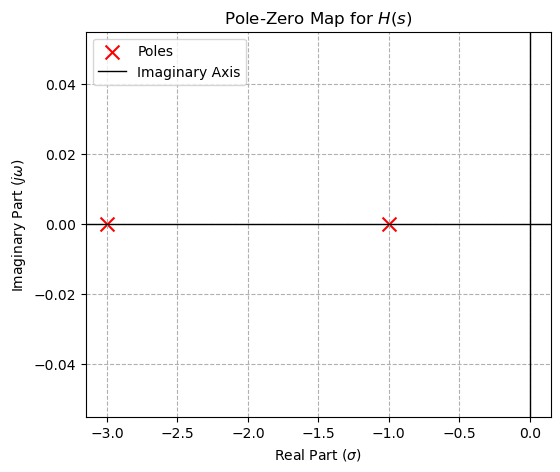

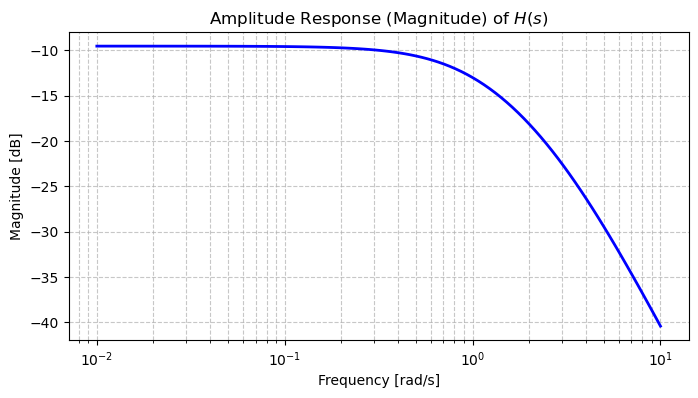

In [39]:
# Define the Laplace variable 's' as a mathematical symbol
s = sp.Symbol('s')

# Define the individual transfer functions H1(s) and H2(s)
H1 = (s + 2) / ((s + 1) * (s + 3))
H2 = 1 / (s + 2)

# Calculate the cascaded transfer function H(s)
H_s = H1 * H2

# Simplify the expression
H_s_simplified = sp.simplify(H_s)

# Display the result
display(Math(r'H(s) = ' + sp.latex(H_s_simplified)))

# Define The denominator coefficients
num_H = [1]
den_H = [1, 4, 3]
sys_H = signal.TransferFunction(num_H, den_H)

#Pole-Zero Map
poles_H = sys_H.poles
zeros_H = sys_H.zeros

#plooting the graph
plt.figure(figsize=(6, 5))
plt.scatter(np.real(poles_H), np.imag(poles_H), s=100, marker='x', color='red', label='Poles')
if len(zeros_H) > 0:
    plt.scatter(np.real(zeros_H), np.imag(zeros_H), s=100, marker='o', color='blue', label='Zeros')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1, label='Imaginary Axis')
plt.grid(True, linestyle='--')
plt.title('Pole-Zero Map for $H(s)$')
plt.xlabel(r'Real Part ($\sigma$)')
plt.ylabel(r'Imaginary Part ($j\omega$)')
plt.legend()
plt.show()

# Amplitude Response 
w_H, mag_H, phase_H = signal.bode(sys_H)

plt.figure(figsize=(8, 4))
plt.semilogx(w_H, mag_H, color='blue', linewidth=2)
plt.title('Amplitude Response (Magnitude) of $H(s)$')
plt.xlabel('Frequency [rad/s]')
plt.ylabel('Magnitude [dB]')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

**Plot analysis (Section A):**

* **Pole-zero map:** there are two poles, at $-1$ and at $-3$ (the red X marks). Both are in the left half-plane, so the system is stable. They also lie exactly on the real axis (no imaginary part), so the response is smooth and decays to zero without oscillations.

* **Amplitude response:** the plot shows how the system treats different frequencies, and it is the classic behavior of a low-pass filter. At low frequencies (left side of the plot) the curve is flat and high, so slow changes pass through easily. At higher frequencies (moving right) the curve drops sharply, so fast changes are filtered out.

### Section B - Closed-Loop Transfer Function T(s)

We find the closed-loop transfer function $T(s) = \frac{Y(s)}{X(s)}$ directly from the block diagram.

1. **Summing junction (error):** the signal entering the forward path is the difference between the input and the fed-back output. We denote it $E(s)$:
$$E(s) = X(s) - Y(s)$$

2. **Forward path:** the output $Y(s)$ is the error $E(s)$ passed through the forward-path transfer function $H(s)$:
$$Y(s) = E(s) \cdot H(s)$$

Substituting the first equation into the second:
$$Y(s) = [X(s) - Y(s)] \cdot H(s)$$

Expanding and rearranging to isolate $Y(s)$:
$$Y(s) = X(s)H(s) - Y(s)H(s)$$
$$Y(s) + Y(s)H(s) = X(s)H(s)$$
$$Y(s)[1 + H(s)] = X(s)H(s)$$

Dividing gives the overall transfer function:
$$T(s) = \frac{Y(s)}{X(s)} = \frac{H(s)}{1 + H(s)}$$

Now we substitute $H(s) = \frac{1}{(s+1)(s+3)}$ from Section A:
$$T(s) = \frac{\frac{1}{(s+1)(s+3)}}{1 + \frac{1}{(s+1)(s+3)}}$$

Multiplying the numerator and denominator by $(s+1)(s+3)$:
$$T(s) = \frac{1}{(s+1)(s+3) + 1} = \frac{1}{(s^2 + 4s + 3) + 1} = \frac{1}{s^2 + 4s + 4}$$

The denominator is a perfect square:
$$T(s) = \frac{1}{(s+2)^2}$$

In [42]:
# We already have 's' and 'H_s_simplified' defined from Section A
# Calculate T(s) = H(s) / (1 + H(s))
T_s = H_s_simplified / (1 + H_s_simplified)

# Simplify the complex fraction
T_s_simplified = sp.simplify(T_s)

# Display the final closed-loop transfer function
display(Math(r'T(s) = ' + sp.latex(T_s_simplified)))

<IPython.core.display.Math object>

### Sections C & D - Region of Convergence (ROC) and Stability

**Section C - Region of convergence (ROC):**
In the previous section we found the closed-loop transfer function:
$$T(s) = \frac{1}{(s+2)^2}$$
It has a double pole at $s = -2$.
We are told that $T(s)$ is **causal**. For a causal system, the ROC in the Laplace plane is always a right half-plane, to the right of the rightmost pole.
Since the only pole is at $s = -2$, the ROC is:
$$ROC: Re\{s\} > -2$$

**Section D - BIBO stability:**
An LTI system is BIBO stable if and only if the ROC of its transfer function contains the imaginary axis ($j\omega$), i.e. the line $Re\{s\} = 0$.
The ROC we found is $Re\{s\} > -2$, and $0 > -2$.
So the imaginary axis lies entirely inside the ROC, and **the system is BIBO stable**.

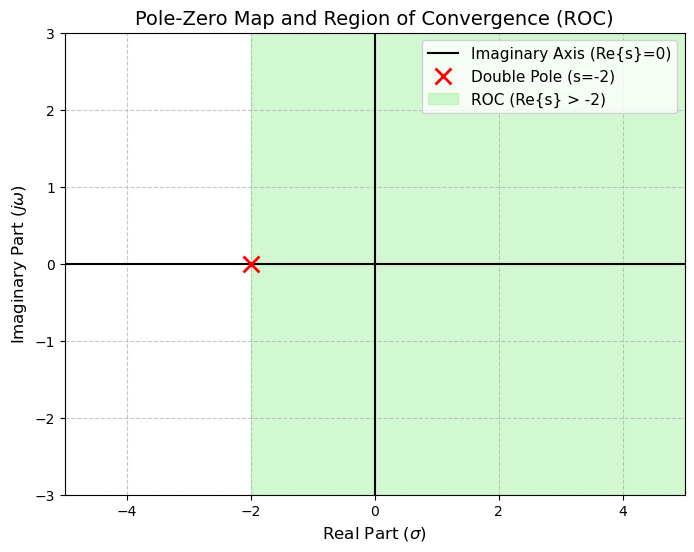

In [44]:
plt.figure(figsize=(8, 6))
# Plot the real and imaginary axes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5, label='Imaginary Axis (Re{s}=0)')
# Mark the double pole at s = -2
plt.plot(-2, 0, 'rx', markersize=12, markeredgewidth=2, label='Double Pole (s=-2)')
# Shade the Region of Convergence (ROC) where Re{s} > -2
plt.axvspan(-2, 5, color='lightgreen', alpha=0.4, label='ROC (Re{s} > -2)')
# Formatting the plot
plt.title('Pole-Zero Map and Region of Convergence (ROC)', fontsize=14)
plt.xlabel('Real Part ($\\sigma$)', fontsize=12)
plt.ylabel('Imaginary Part ($j\\omega$)', fontsize=12)
plt.xlim(-5, 5)
plt.ylim(-3, 3)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=11)
plt.show()

**Plot analysis (illustrating Sections C and D):**
The plot shows the close relation between the pole locations, the region of convergence (ROC) and stability:

* **The pole (red X):** marks the double pole of the system at $s = -2$.
* **The ROC (green area):** since the system is causal, the ROC extends to the right of the rightmost pole. The shaded area starts at $-2$ and continues to the right ($Re\{s\} > -2$).
* **Stability:** the vertical black line at zero is the imaginary axis ($j\omega$). The stability condition is that the ROC contains this axis. The plot shows the green area covering the imaginary axis, which confirms visually that the system is BIBO stable.

### Section E - System Response to a Step Input y(t)

We need the output $y(t)$ for a step input $x(t) = u(t)$.

1. **Laplace domain:** the Laplace transform of the unit step is:
$$X(s) = \frac{1}{s}$$

2. **Computing the output $Y(s)$:**
The output is the product of the input and the closed-loop transfer function:
$$Y(s) = X(s) \cdot T(s) = \frac{1}{s} \cdot \frac{1}{(s+2)^2} = \frac{1}{s(s+2)^2}$$

3. **Partial fraction expansion:**
To invert the transform, we split the expression according to its poles (a single pole at zero and a double pole at $-2$):
$$\frac{1}{s(s+2)^2} = \frac{A}{s} + \frac{B}{s+2} + \frac{C}{(s+2)^2}$$

Using a common denominator and comparing numerators:
$$1 = A(s+2)^2 + Bs(s+2) + Cs$$
$$1 = A(s^2+4s+4) + B(s^2+2s) + Cs$$

Comparing coefficients of powers of $s$:
* For $s^2$: $A + B = 0 \implies B = -A$
* For $s^0$ (constant term): $4A = 1 \implies A = 0.25$
* Therefore: $B = -0.25$
* For $s^1$: $4A + 2B + C = 0 \implies 4(0.25) + 2(-0.25) + C = 0 \implies 1 - 0.5 + C = 0 \implies C = -0.5$

Substituting the coefficients back:
$$Y(s) = \frac{1/4}{s} - \frac{1/4}{s+2} - \frac{1/2}{(s+2)^2}$$

4. **Inverse Laplace transform:**
Using the transform table:
* $\frac{1}{s} \xrightarrow{L^{-1}} u(t)$
* $\frac{1}{s+a} \xrightarrow{L^{-1}} e^{-at}u(t)$
* $\frac{1}{(s+a)^2} \xrightarrow{L^{-1}} t \cdot e^{-at}u(t)$

The final time response is:
$$y(t) = \left( \frac{1}{4} - \frac{1}{4}e^{-2t} - \frac{1}{2}t e^{-2t} \right) u(t)$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

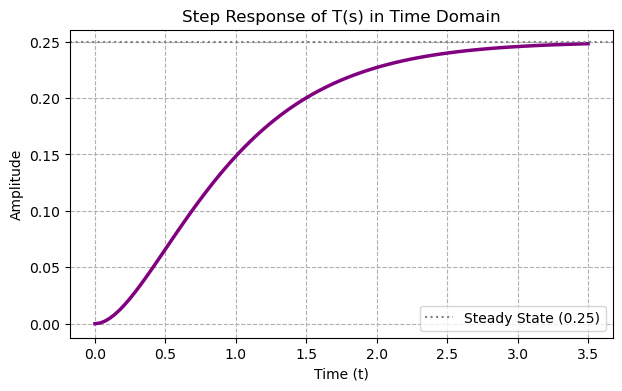

In [47]:
# Define symbolic variables
s = sp.Symbol('s')
t = sp.Symbol('t', positive=True) # Time is always positive (causal)

# Define the closed-loop transfer function T(s) we found earlier
T_s = 1 / (s + 2)**2

# Define the step input X(s) = 1/s
X_s = 1 / s

# Calculate the output Y(s) = X(s) * T(s)
Y_s = X_s * T_s

# Perform Partial Fraction Expansion (apart)
Y_s_partial = sp.apart(Y_s, s)
display(Math(r'\text{Partial Fractions: } Y(s) = ' + sp.latex(Y_s_partial)))

# Calculate the Inverse Laplace Transform
y_t = sp.inverse_laplace_transform(Y_s, s, t)
display(Math(r'\text{Step Response: } y(t) = ' + sp.latex(y_t)))

# Convert transfer function to numerical format for plotting
system_T = signal.TransferFunction([1], [1, 4, 4])
t_step, y_step = signal.step(system_T)

plt.figure(figsize=(7, 4))
plt.plot(t_step, y_step, color='purple', linewidth=2.5)
plt.title('Step Response of T(s) in Time Domain')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')
plt.axhline(0.25, color='gray', linestyle=':', label='Steady State (0.25)')
plt.legend()
plt.show()

**Plot analysis - step response:**
The step response rises smoothly and settles at $0.25$ without oscillations. This is expected, since the poles have no imaginary part (critical damping).

### Section F - Impulse Response h(t)

The closed-loop transfer function $T(s)$ is the Laplace transform of the impulse response $h(t)$. So we find $h(t)$ directly by inverting $T(s)$:
$$T(s) = \frac{1}{(s+2)^2}$$

From the Laplace transform table:
$$\frac{1}{(s+a)^2} \xrightarrow{L^{-1}} t \cdot e^{-at}u(t)$$

Substituting $a=2$ gives the impulse response:
$$h(t) = t \cdot e^{-2t} u(t)$$

*(Note: the same result can be obtained by differentiating the step response, but the direct inverse transform is shorter.)*

<IPython.core.display.Math object>

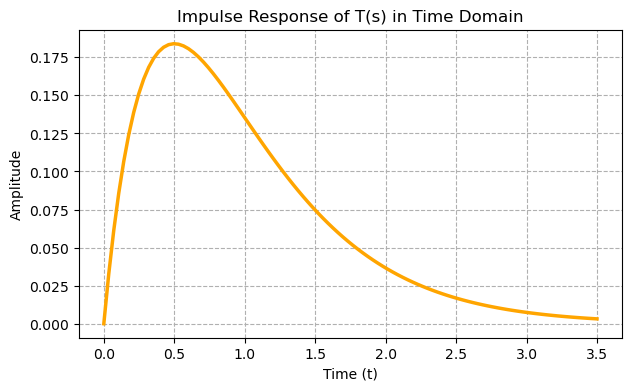

In [50]:
# Calculate the Impulse Response h(t) via Inverse Laplace Transform of T(s)
h_t = sp.inverse_laplace_transform(T_s, s, t)

# Display the final impulse response
display(Math(r'\text{Impulse Response: } h(t) = ' + sp.latex(h_t)))
# Calculate and plot the impulse response
system_T = signal.TransferFunction([1], [1, 4, 4])
t_impulse, y_impulse = signal.impulse(system_T)

plt.figure(figsize=(7, 4))
plt.plot(t_impulse, y_impulse, color='orange', linewidth=2.5)
plt.title('Impulse Response of T(s) in Time Domain')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')
plt.show()

**Plot analysis - impulse response:**
The impulse response is the derivative of the step response. It starts at 0, rises to a peak and then decays back to zero, as expected.

### Section G - System Stability with Feedback Gain K

A gain $K$ is added to the feedback path. We need the range of $K$ for which the system remains stable.

1. **The new transfer function:**
The new summing-junction equation is $E(s) = X(s) - K \cdot Y(s)$.
Substituting into the forward-path equation $Y(s) = E(s) \cdot H(s)$:
$$Y(s) = [X(s) - K \cdot Y(s)]H(s)$$
$$Y(s) + K \cdot Y(s)H(s) = X(s)H(s)$$
$$T_K(s) = \frac{Y(s)}{X(s)} = \frac{H(s)}{1 + K \cdot H(s)}$$

Substituting $H(s) = \frac{1}{(s+1)(s+3)} = \frac{1}{s^2+4s+3}$ and simplifying:
$$T_K(s) = \frac{\frac{1}{s^2+4s+3}}{1 + \frac{K}{s^2+4s+3}} = \frac{1}{s^2+4s+3+K}$$

2. **Stability analysis (finding the poles):**
For stability, all poles (roots of the denominator) must have a negative real part.
Setting the denominator to zero:
$$s^2 + 4s + (3+K) = 0$$
Using the quadratic formula:
$$s_{1,2} = \frac{-4 \pm \sqrt{16 - 4(3+K)}}{2} = -2 \pm \sqrt{4 - (3+K)} = -2 \pm \sqrt{1-K}$$

3. **Conditions on $K$:**
We split into two cases according to the expression under the square root:
* **Case A: $1-K \le 0 \implies K \ge 1$**
  The square root is imaginary, so the poles are complex: $s = -2 \pm j\sqrt{K-1}$.
  The real part is exactly $-2$. Since $-2 < 0$, the system is always **stable** in this range.

* **Case B: $1-K > 0 \implies K < 1$**
  The square root is real, so there are two real poles.
  For stability, the rightmost pole (the one with the plus sign) must be negative:
  $$-2 + \sqrt{1-K} < 0$$
  $$\sqrt{1-K} < 2$$
  $$1-K < 4 \implies K > -3$$
  So in this range the system is stable only for $-3 < K < 1$.

**Final conclusion:**
Combining the two cases, the system is stable for every **$K > -3$**.

<IPython.core.display.Math object>

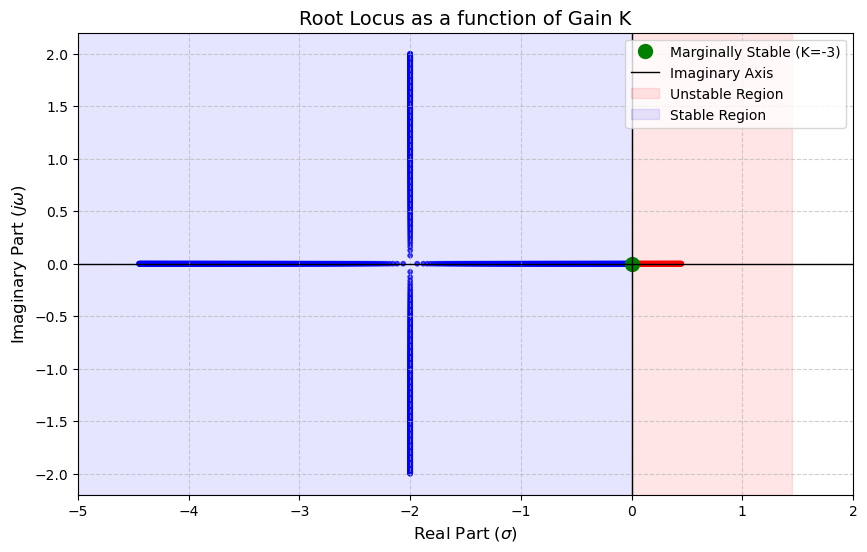

In [53]:
K_sym = sp.Symbol('K', real=True)
H_s = 1 / ((s + 1) * (s + 3))

# Calculate the new transfer function with gain K
T_K = H_s / (1 + K_sym * H_s)
T_K_simplified = sp.simplify(T_K)

# Display the symbolic Transfer Function
display(Math(r'T_K(s) = ' + sp.latex(T_K_simplified)))

# 2. Visual Root Locus Analysis
K_values = np.linspace(-5, 5, 1000)
poles_real = []
poles_imag = []
colors = []

# Calculate roots numerically for different K values
for K in K_values:
    # Denominator coefficients for s^2 + 4s + (3+K)
    coeffs = [1, 4, 3 + K]
    roots = np.roots(coeffs)
    
    for r in roots:
        poles_real.append(np.real(r))
        poles_imag.append(np.imag(r))
        # Color red if unstable (real part >= 0), blue if stable
        if np.real(r) >= 0:
            colors.append('red')
        else:
            colors.append('blue')

plt.figure(figsize=(10, 6))
plt.scatter(poles_real, poles_imag, c=colors, s=10, alpha=0.7)
# Mark the critical point where K = -3
plt.plot(0, 0, 'go', markersize=10, label='Marginally Stable (K=-3)')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1, label='Imaginary Axis')
plt.axvspan(0, max(poles_real)+1, color='red', alpha=0.1, label='Unstable Region')
plt.axvspan(min(poles_real)-1, 0, color='blue', alpha=0.1, label='Stable Region')
plt.title('Root Locus as a function of Gain K', fontsize=14)
plt.xlabel('Real Part ($\\sigma$)', fontsize=12)
plt.ylabel('Imaginary Part ($j\\omega$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.xlim(-5, 2)
plt.show()

**Plot analysis:**
The pole map confirms the algebraic result visually. As long as the gain satisfies $K > -3$, all poles are in the left half-plane (negative real part) and the system stays stable. When $K$ reaches the threshold $-3$ (the green point), one pole lands exactly on the imaginary axis. Below that, the pole crosses into the right half-plane, gets a positive real part, and the system becomes unstable and diverges.